# NeuroScape 2.0: first look at 2024–2025

Exploratory notebook on the (provisional) NeuroScape 2.0 assembly. It is not part of the paper and does not touch the v1 data.

1. Research vs review articles over 1999–2025 and in 2024/2025
2. The fastest growing and declining clusters selected in v1 (1999–2023), followed through 2025
3. An updated selection of the fastest growing and declining clusters over 1999–2025

Growth is computed as in `results_03_growth_trends.ipynb`: the slope of a linear fit to a cluster's annual article count, divided by its total number of articles.

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('notebook')

BASEPATH = os.environ.get('BASEPATH_V2', '/media/mario/HDD/Data/NeuroScape_v2')
csv_path = os.path.join(BASEPATH, 'Public', 'Data', 'CSV')

article_df = pd.read_csv(os.path.join(csv_path, 'neuroscience_articles_1999-2025.csv'))
cluster_df = pd.read_csv(os.path.join(csv_path, 'neuroscience_clusters_1999-2025.csv'))
cluster_titles = cluster_df.set_index('Cluster ID')['Title'].str.split(':').str[0]

# v1 articles are kept unchanged in v2 ('Added In' == 'v1.0')
v1_df = article_df[article_df['Added In'] == 'v1.0']

print(f'{len(article_df):,} articles in v2, {len(v1_df):,} of them from v1')
article_df.groupby(['Added In', 'Year']).size().unstack(0).fillna(0).astype(int).tail(6)

/tmp/ipykernel_248054/2238938131.py:12: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  article_df = pd.read_csv(os.path.join(csv_path, 'neuroscience_articles_1999-2025.csv'))


540,493 articles in v2, 461,316 of them from v1


Added In,v1.0,v2.0,v2.0-late
Year,,,
2020,25156,0,1549
2021,27109,0,1823
2022,24588,0,2341
2023,23658,0,2679
2024,0,27371,0
2025,0,33622,0


In [5]:
def compute_normalized_annual_growth(data):
    """
    Compute the size-adjusted annual growth rate of each cluster (as in results_03).

    Parameters:
    - data: pd.DataFrame

    Returns:
    - normalized_growth: pd.Series
    """
    cluster_count_per_year = data.groupby(['Year', 'Cluster ID']).size().unstack().fillna(0)
    beta = cluster_count_per_year.apply(
        lambda x: pd.Series(
            np.polyfit(cluster_count_per_year.index, x, 1), index=['Slope', 'Intercept']), axis=0)

    return beta.loc['Slope'] / cluster_count_per_year.sum()


def compute_field_growth(data):
    """
    Compute the size-adjusted annual growth rate of neuroscience as a whole.
    """
    count_per_year = data.groupby('Year').size()
    slope = np.polyfit(count_per_year.index, count_per_year.values, 1)[0]

    return slope / count_per_year.sum()


def plot_cluster_counts(data, clusters, title, split_year=None):
    """
    Plot the number of articles per year for the given clusters.
    """
    counts = data[data['Cluster ID'].isin(clusters)].groupby(['Year', 'Cluster ID']).size().unstack().fillna(0)
    colors = sns.color_palette('colorblind', len(clusters))

    fig, ax = plt.subplots(figsize=(10, 5))
    for color, cluster in zip(colors, clusters):
        ax.plot(counts.index, counts[cluster], color=color, linewidth=1.5,
                label=f'{cluster:3d} {cluster_titles[cluster][:45]}')
    if split_year is not None:
        ax.axvline(split_year + 0.5, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Articles')
    ax.set_title(title)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
    sns.despine()
    plt.tight_layout()
    plt.show()

## 1. Research vs review articles

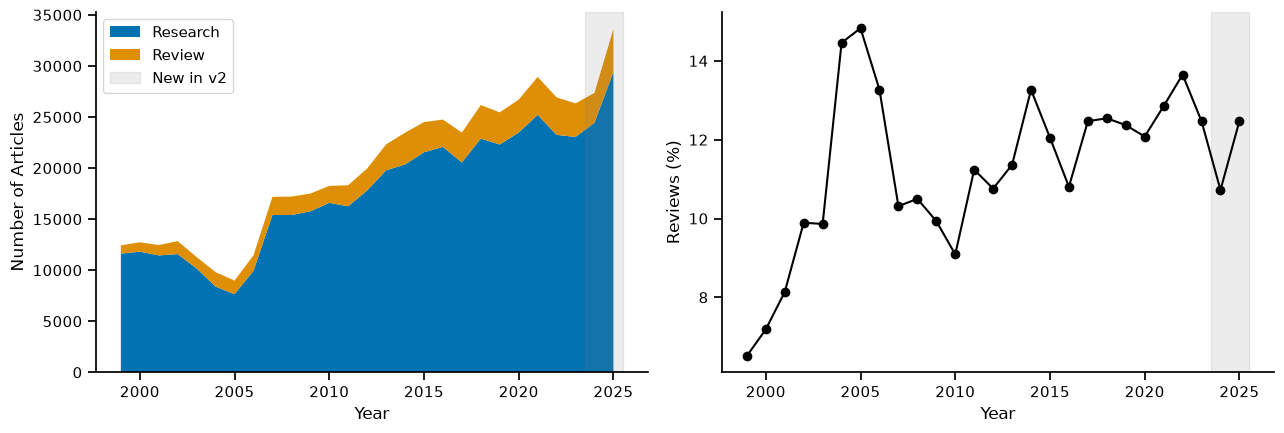

Type,Research,Review,Review Share
Year,,,
2020,23479,3226,0.120801
2021,25214,3718,0.128508
2022,23253,3676,0.136507
2023,23053,3284,0.124691
2024,24436,2935,0.107230
2025,29428,4194,0.124740


In [6]:
type_per_year = article_df.groupby(['Year', 'Type']).size().unstack().fillna(0).astype(int)
type_per_year['Review Share'] = type_per_year['Review'] / type_per_year[['Research', 'Review']].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].stackplot(type_per_year.index, type_per_year['Research'], type_per_year['Review'],
                  labels=['Research', 'Review'], colors=sns.color_palette('colorblind', 2))
axes[0].axvspan(2023.5, 2025.5, color='grey', alpha=0.15, label='New in v2')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Articles')
axes[0].legend(loc='upper left')

axes[1].plot(type_per_year.index, 100 * type_per_year['Review Share'], marker='o', color='black')
axes[1].axvspan(2023.5, 2025.5, color='grey', alpha=0.15)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Reviews (%)')

sns.despine()
plt.tight_layout()
plt.show()

type_per_year.tail(6)

### 2024 and 2025 only

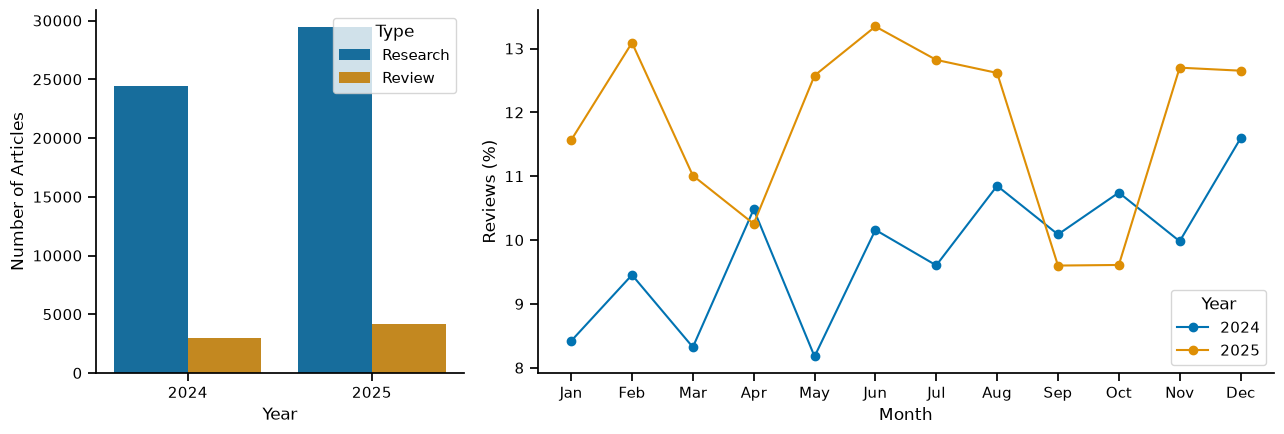

Articles without a month: 9754


Type,Research,Review
Year,,
2024,24436,2935
2025,29428,4194


In [7]:
recent_df = article_df[article_df['Year'].isin([2024, 2025])]
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios': [1, 2]})

sns.countplot(data=recent_df, x='Year', hue='Type', hue_order=['Research', 'Review'],
              palette='colorblind', ax=axes[0])
axes[0].set_ylabel('Number of Articles')

month_share = (recent_df.assign(Review=recent_df['Type'] == 'Review')
               .groupby(['Year', 'Month'])['Review'].mean().mul(100)
               .unstack(0).reindex(month_order))
month_share.plot(marker='o', ax=axes[1], color=sns.color_palette('colorblind', 2))
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Reviews (%)')
axes[1].set_xticks(range(12), month_order)

sns.despine()
plt.tight_layout()
plt.show()

print('Articles without a month:', recent_df['Month'].isna().sum())
recent_df.groupby(['Year', 'Type']).size().unstack()

Review share per cluster: 1999–2023 vs 2024–2025. Clusters above the diagonal have a larger share of reviews in the new years (only clusters with at least 50 new articles).

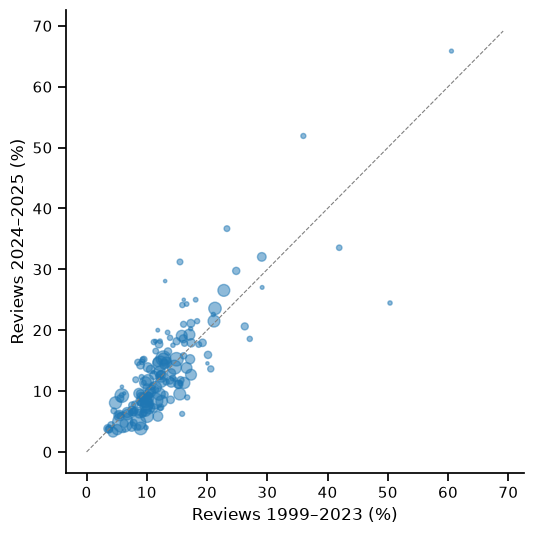

,Title,Change (pp)
Cluster ID,,
171,Neurological and Neuropsychiatric Manifestatio...,-25.9
114,Morphological and Functional Dynamics of Dendr...,-9.6
129,Dynamics and Mechanisms of Synaptic Plasticity...,-8.5
159,Consciousness and the Mind-Brain Interface,-8.4
151,Neurophysiological and Genetic Insights into M...,-7.7
136,Orexin/Hypocretin System in Sleep-Wake Regulat...,8.9
134,Innovative Strategies for Blood-Brain Barrier ...,13.4
119,Glutamate Metabolism and Transport Dynamics in...,15.0
125,Metal Ion Homeostasis and Neurodegeneration,15.7


In [8]:
article_df['Period'] = np.where(article_df['Year'] >= 2024, '2024-2025', '1999-2023')
cluster_review = (article_df.assign(Review=article_df['Type'] == 'Review')
                  .groupby(['Cluster ID', 'Period'])['Review'].agg(['mean', 'size']).unstack())
cluster_review = cluster_review[cluster_review[('size', '2024-2025')] >= 50]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(100 * cluster_review[('mean', '1999-2023')], 100 * cluster_review[('mean', '2024-2025')],
           s=cluster_review[('size', '2024-2025')] / 10, alpha=0.5)
limit = 100 * cluster_review['mean'].max().max() * 1.05
ax.plot([0, limit], [0, limit], color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Reviews 1999–2023 (%)')
ax.set_ylabel('Reviews 2024–2025 (%)')
sns.despine()
plt.tight_layout()
plt.show()

change = (cluster_review[('mean', '2024-2025')] - cluster_review[('mean', '1999-2023')]).mul(100)
pd.DataFrame({'Title': cluster_titles[change.index], 'Change (pp)': change.round(1)}).sort_values('Change (pp)').iloc[np.r_[0:5, -5:0]]

## 2. v1 selection, followed through 2025

The 10 fastest growing and 10 fastest declining clusters selected on v1 (1999–2023), as in Figure 3 of the paper. Counts for 2024 and 2025 (right of the dashed line) come from v2.

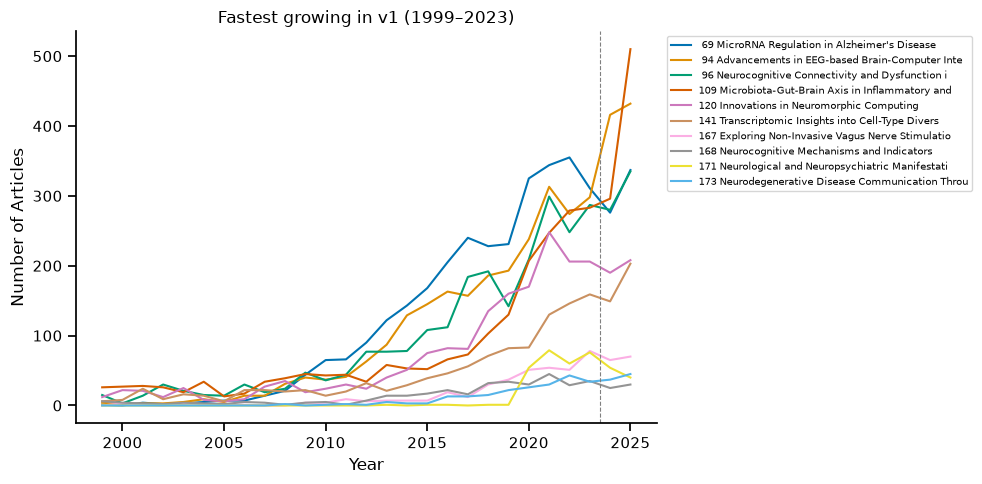

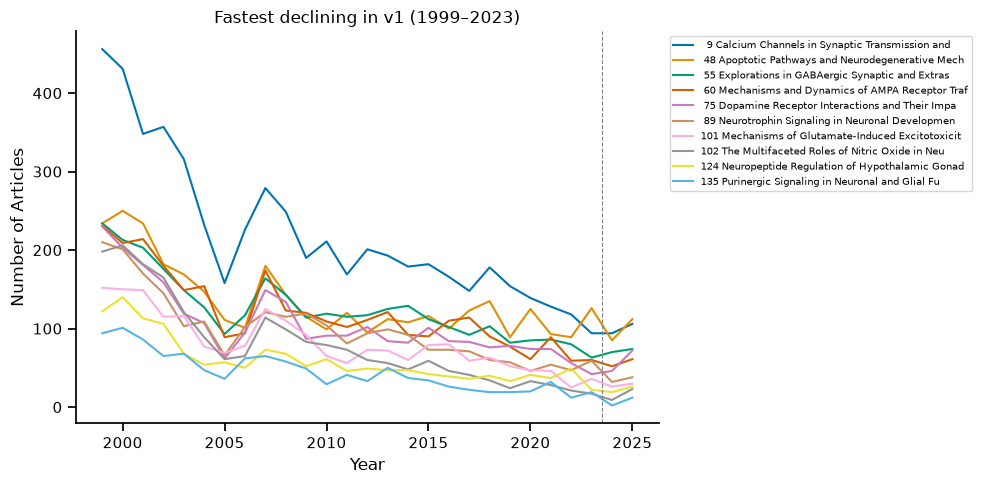

In [9]:
num_selected = 10

v1_growth = compute_normalized_annual_growth(v1_df)
v1_field_growth = compute_field_growth(v1_df)

v1_growing = sorted(v1_growth[v1_growth > v1_field_growth].sort_values(ascending=False).head(num_selected).index)
v1_declining = sorted(v1_growth[v1_growth < 0].sort_values().head(num_selected).index)

plot_cluster_counts(article_df, v1_growing, 'Fastest growing in v1 (1999–2023)', split_year=2023)
plot_cluster_counts(article_df, v1_declining, 'Fastest declining in v1 (1999–2023)', split_year=2023)

## 3. Updated selection (1999–2025)

The same selection on all of v2. `v1 Rank` is the cluster's rank in the v1 selection (growing: descending, declining: ascending); the field-wide growth threshold is recomputed on 1999–2025.

In [10]:
v2_growth = compute_normalized_annual_growth(article_df)
v2_field_growth = compute_field_growth(article_df)
print(f'Normalized growth of neuroscience: v1 {v1_field_growth:.4f}, v2 {v2_field_growth:.4f}')

v2_growing = v2_growth[v2_growth > v2_field_growth].sort_values(ascending=False).head(num_selected).index
v2_declining = v2_growth[v2_growth < 0].sort_values().head(num_selected).index

v1_rank_growing = v1_growth.rank(ascending=False).astype(int)
v1_rank_declining = v1_growth.rank(ascending=True).astype(int)


def selection_table(clusters, v1_selection, v1_rank):
    return pd.DataFrame({
        'Title': cluster_titles[clusters],
        'Growth v2': v2_growth[clusters].round(4),
        'Growth v1': v1_growth[clusters].round(4),
        'v1 Rank': v1_rank[clusters],
        'In v1 Selection': [cluster in v1_selection for cluster in clusters],
    })


display(selection_table(v2_growing, v1_growing, v1_rank_growing))
display(selection_table(v2_declining, v1_declining, v1_rank_declining))

print('Dropped from growing:', sorted(set(v1_growing) - set(v2_growing)))
print('Dropped from declining:', sorted(set(v1_declining) - set(v2_declining)))

Normalized growth of neuroscience: v1 0.0015, v2 0.0015


,Title,Growth v2,Growth v1,v1 Rank,In v1 Selection
Cluster ID,,,,,
171,Neurological and Neuropsychiatric Manifestatio...,0.0063,0.0080,1,True
173,Neurodegenerative Disease Communication Throug...,0.0055,0.0067,2,True
167,Exploring Non-Invasive Vagus Nerve Stimulation,0.0052,0.0062,3,True
94,Advancements in EEG-based Brain-Computer Inter...,0.0047,0.0053,4,True
85,Biomarkers and Neuroimaging in Alzheimer's Dis...,0.0044,0.0042,16,False
109,Microbiota-Gut-Brain Axis in Inflammatory and ...,0.0044,0.0044,9,True
69,MicroRNA Regulation in Alzheimer's Disease,0.0043,0.0052,5,True
166,Neural Mechanisms and Effects of Acupuncture o...,0.0043,0.0041,21,False
96,Neurocognitive Connectivity and Dysfunction in...,0.0042,0.0046,7,True


,Title,Growth v2,Growth v1,v1 Rank,In v1 Selection
Cluster ID,,,,,
102,The Multifaceted Roles of Nitric Oxide in Neur...,-0.0031,-0.0034,1,True
135,Purinergic Signaling in Neuronal and Glial Fun...,-0.0026,-0.0027,2,True
124,Neuropeptide Regulation of Hypothalamic Gonado...,-0.0021,-0.0023,3,True
89,Neurotrophin Signaling in Neuronal Development...,-0.0020,-0.0021,4,True
101,Mechanisms of Glutamate-Induced Excitotoxicity...,-0.0020,-0.0021,6,True
9,Calcium Channels in Synaptic Transmission and ...,-0.0019,-0.0021,5,True
60,Mechanisms and Dynamics of AMPA Receptor Traff...,-0.0017,-0.0019,8,True
75,Dopamine Receptor Interactions and Their Impac...,-0.0017,-0.0019,7,True
55,Explorations in GABAergic Synaptic and Extrasy...,-0.0015,-0.0016,9,True


Dropped from growing: [120, 168]
Dropped from declining: [48]


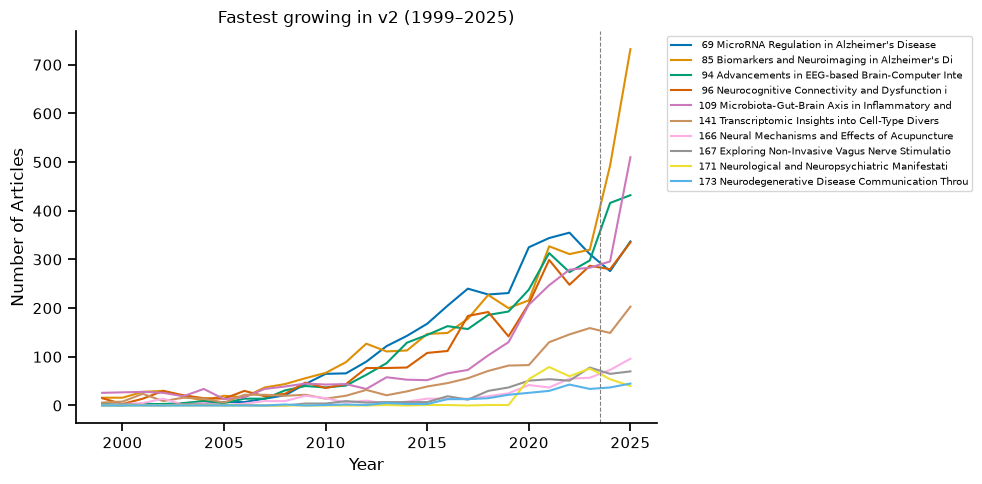

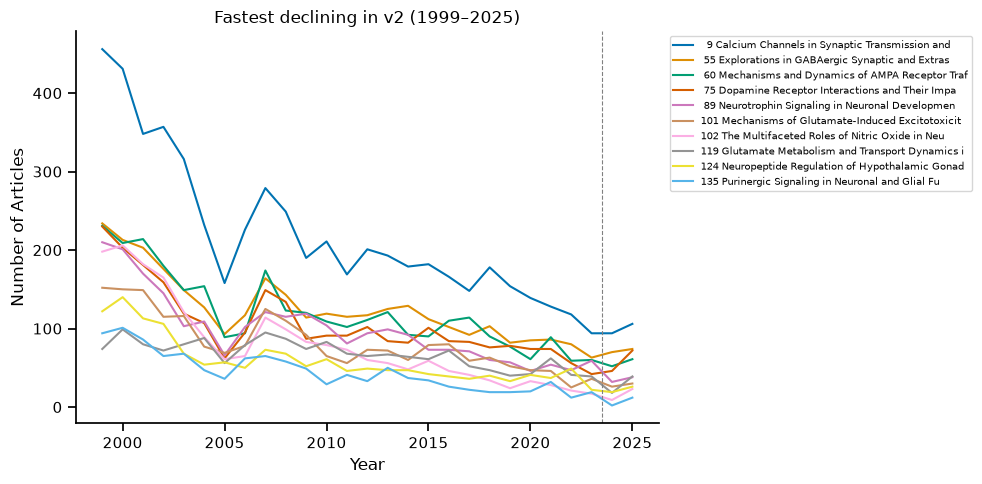

In [11]:
plot_cluster_counts(article_df, sorted(v2_growing), 'Fastest growing in v2 (1999–2025)', split_year=2023)
plot_cluster_counts(article_df, sorted(v2_declining), 'Fastest declining in v2 (1999–2025)', split_year=2023)

How the growth classes (growing / stable / declining, as in the paper) change from v1 to v2:

In [12]:
def growth_class(growth, field_growth):
    return pd.cut(growth, [-np.inf, 0, field_growth, np.inf], labels=['Declining', 'Stable', 'Growing'], right=False)

pd.crosstab(growth_class(v1_growth, v1_field_growth).rename('v1'),
            growth_class(v2_growth, v2_field_growth).rename('v2'), margins=True)

v2,Declining,Stable,Growing,All
v1,,,,
Declining,26,1,0,27
Stable,2,52,3,57
Growing,0,4,87,91
All,28,57,90,175
